In [1]:
%matplotlib inline

import sys

sys.path.append('..')

import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import product
from datetime import datetime
import os
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from open_ocean.utils import convert_climatology_to_ocean_areas
import open_ocean.gridder as gridder
import open_ocean.interpolation as io

In [2]:
data_dir = Path(os.getenv("OODIR"))

In [3]:
ice = xr.open_dataset(data_dir / "IQUAM" / "InputData" / "HadISST.2.2.0.0_sea_ice_concentration.nc",
                          engine='netcdf4')

In [4]:
cci_path =  data_dir / "SST_CCI" / "SST_ANOM_100_19800101_20250630_regridded"
cci_files = cci_path.glob('*_regridded_sst.nc')
cci = xr.open_mfdataset(cci_files)



Text(-175, -87, 'CCI')

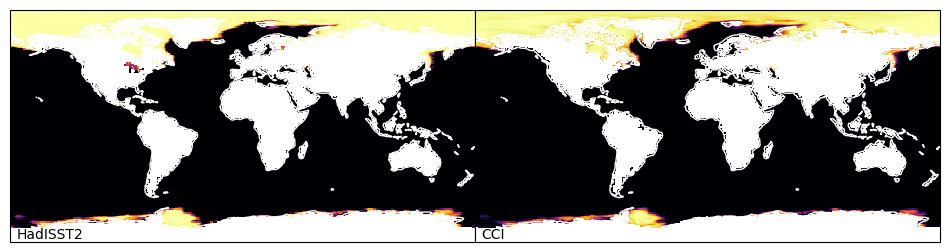

In [9]:
date = f"2005-02-15"
iceym = ice.sel(time=date, method="nearest")
cciym = cci.sel(time=date, method="nearest")


hlon = iceym.sic.longitude
hlat = iceym.sic.latitude

clon = cciym.sea_ice_fraction.lon
clat = cciym.sea_ice_fraction.lat

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,18), subplot_kw=dict(projection=ccrs.PlateCarree()))
plt.subplots_adjust(wspace=0, hspace=0)

axes[0].coastlines(lw=1, color='w')
x = axes[0].pcolormesh(hlon, hlat, iceym.sic, vmin=0.0, vmax=1.0, cmap='inferno')
axes[0].text(-175, -87, 'HadISST2', color='black')

axes[1].coastlines(lw=1, color='w')
x = axes[1].pcolormesh(clon, clat, cciym.sea_ice_fraction, vmin=0.0, vmax=1.0, cmap='inferno')
axes[1].text(-175, -87, 'CCI', color='black')


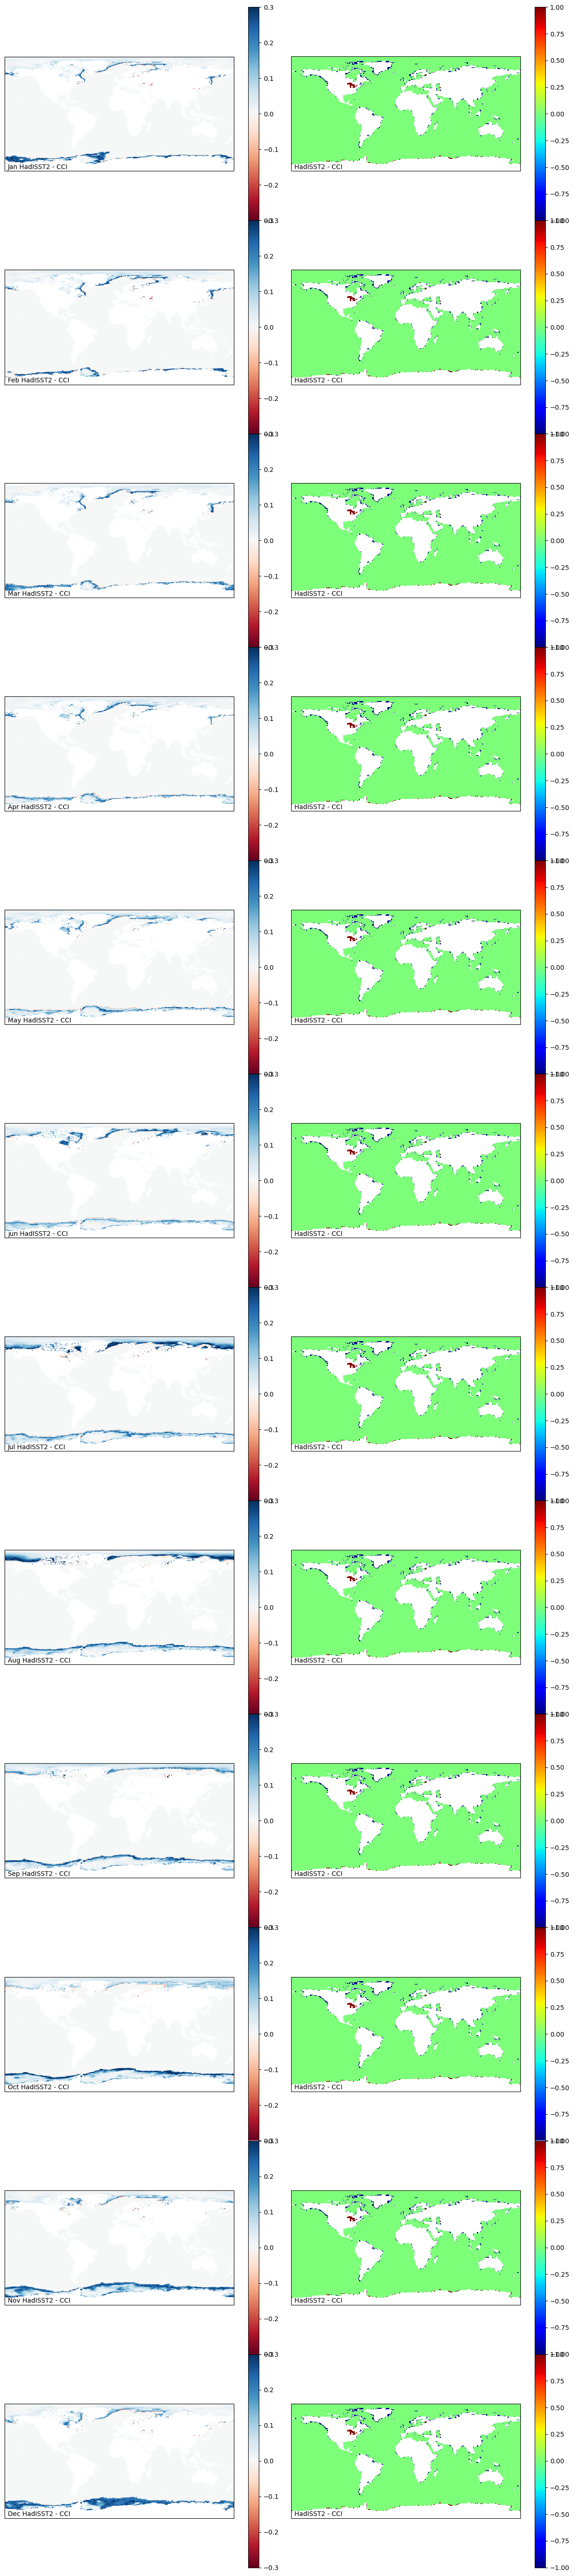

In [16]:
fig, axes = plt.subplots(nrows=12, ncols=2, figsize=(16,72), subplot_kw=dict(projection=ccrs.PlateCarree()))
plt.subplots_adjust(wspace=0, hspace=0)
for month in range(1,13):
    i= month-1
    date = f"2005-{month:02d}-15"
    
    iceym = ice.sel(time=date, method="nearest")
    cciym = cci.sel(time=date, method="nearest")
    
    adjusted_cci_grid = np.roll(np.flip(cciym.sea_ice_fraction.values, axis=0), 180, axis=1)
    diff = iceym.sic.values - adjusted_cci_grid
    
    mask = np.zeros_like(diff)
    
    sel1 = np.isnan(adjusted_cci_grid) & ~np.isnan(iceym.sic.values)
    sel2 = ~np.isnan(adjusted_cci_grid) & np.isnan(iceym.sic.values)
    sel3 = np.isnan(adjusted_cci_grid) & np.isnan(iceym.sic.values)
    sel4 = ~np.isnan(adjusted_cci_grid) & ~np.isnan(iceym.sic.values)
    
    mask[sel1] = 1
    mask[sel2] = -1
    mask[sel3] = np.nan
    mask[sel4] = 0

    month_names = ['Jan', 'Feb', 'Mar', 'Apr','May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    axes[i,0].coastlines(lw=1, color='w')
    x = axes[i,0].pcolormesh(hlon, hlat, diff, vmin=-0.3, vmax=0.3, cmap='RdBu')
    axes[i,0].text(-175, -87, f'{month_names[i]} HadISST2 - CCI', color='black')
    fig.colorbar(x)
    
    y = axes[i,1].pcolormesh(hlon, hlat, mask, vmin=-1.0, vmax=1.0, cmap='jet')
    axes[i,1].text(-175, -87, 'HadISST2 - CCI', color='black')
    fig.colorbar(y)